# 500 车：冻结模型与 Myopic MCMF 对照

完整 Yellow Manhattan 需求，250 EV + 250 AEV。训练 2025-12-15、16 的 12:00–17:00；两个冻结检查点和 Myopic 在 16 日同一窗口、相同种子下测试。

这是同一对模型的策略机制诊断，测试日参与第二轮训练，不是独立测试集上的泛化评估。连线连接同一种子，菱形为均值；时序阴影为种子间 ±1 标准差。

In [1]:
from pathlib import Path
import json
from IPython.display import display, Markdown, Image
from analyze_nyc_frozen_policy import analyze

ROOT = Path.cwd()
DATA = ROOT / "results/nyc_frozen_policy_500_20260915"
assert (DATA / "completion.json").exists(), "实验尚未全部结束"
summary = analyze(DATA)
display(Markdown((DATA / "report.md").read_text()))

# 500 车冻结策略诊断

完整 Yellow Manhattan 需求，250 EV + 250 AEV；训练 2025-12-15、16 日 12–17 时，统一测试 16 日同一窗口。
训练种子 32；测试种子 [256, 257, 258]。使用生产 NYCTrainer、macro、P3 residual learner、OR-Tools MCMF+SSG、单线程。

两天在线训练 reward：[546153.9492934841, 592211.950933023]。两天需求不同，不能直接据此认定学习改善或退化。

|Method|Reward ($)|EV reward ($)|AEV reward ($)|Completed|EV reject rate|EV empty km|
|---|---:|---:|---:|---:|---:|---:|
|Frozen episode 1|597745.83|320911.51|276834.32|6933.33|2.99%|3447.27|
|Frozen episode 2|597172.22|322439.61|274732.61|6906.33|3.11%|3436.10|
|Myopic MCMF|593718.80|312252.19|281466.61|6949.00|3.43%|3698.68|

第二轮相对第一轮：系统 reward -0.096%，完成订单 -27.00 单。其中 EV 完成订单 +22.00 单、EV reward +1528.10；AEV 完成订单 -49.00 单、AEV reward -2101.71。

EV 平均空驶里程 -0.324%，offer 前平均空闲时间 1.581 → 1.560 分钟，接驾时间 3.741 → 3.732 分钟。EV 分区位置分布相对第一轮的平均 TV 距离为 0.185，说明调度轨迹发生变化。

实际 EV 条件拒单率变化 +0.121 个百分点，但实际 offer 的模型期望接单率变化为 +0.042 个百分点。实际拒单率同时受所提供的订单组合及其抽样结果影响，不能只看拒单事件总数来判断接单概率恶化。

本次结果没有支持“后续学习使 EV 更空闲/更远接驾，再由拒单反馈减少 EV 服务量”的解释：EV 完成量和收益增加，平均空驶没有增加。车辆分布改变与收益恶化不是同一结论。这不能排除原先 3000 车、全天训练、较大 residual beta 下出现不同结果。

上述为同一对训练模型、多个测试种子的均值，不是多个独立训练结果。

|Test seed|Episode 2 − 1 reward ($)|Change (%)|Completed change|EV reject-rate change (pp)|
|---|---:|---:|---:|---:|
|256|-10.50|-0.00|-38|+0.68|
|257|+4315.19|+0.72|+14|-0.31|
|258|-6025.53|-1.01|-57|-0.00|

验证：同种子的初始车辆状态、每步生成需求、CRN 编号一致；相同 offer 的随机 draw 相同；测试期间网络权重不变；订单生命周期计数无缺口。

EV 接单模型的平均 utility 变化可以精确拆为 −0.017×Δidle −0.050×Δpickup +0.101×Δsurge。见 paired_episode2_minus_episode1.json。这描述不同策略实际提供的订单组合，并不单独识别拒单反馈的因果效应；sigmoid 的均值也不等于均值 utility 的 sigmoid。

限制：测试日参与第二轮训练，属于机制诊断；500 车承受完整需求，不代表 3000 车供需比例。五小时截断不追踪 17:00 后的订单完成，窗口末未完成订单不等于最终丢失。训练每个车队累计约 120 次联合 critic 更新，保留各检查点自己的学习步数及 residual beta；不能直接重现全天训练的优化预算和低电量累积。
位置 TV 差异反映车辆分布发生变化，不自动代表变化有害。车辆状态是在每步结束采样，空驶距离来自实际移动增量。

检查点实际学习步数与权重变化见 checkpoint_diagnostics.json；beta 使用现有默认上限 0.3、warmup 500 次计算。本实验保留每轮自己的 beta，因此比较的是完整部署策略（权重和 beta），不是固定 beta 的纯权重消融。
旧的 per-edge training_step 保持 0 不表示未训练；实际学习使用 joint_training_step，两轮分别为 59、119，两个车队的 critic/图编码器/mixer 参数均发生变化。

|训练日|12–17 时生成订单|完成订单|EV 条件拒单率|
|---|---:|---:|---:|
|2025-12-15|32780|6788|3.54%|
|2025-12-16|33162|6868|3.24%|


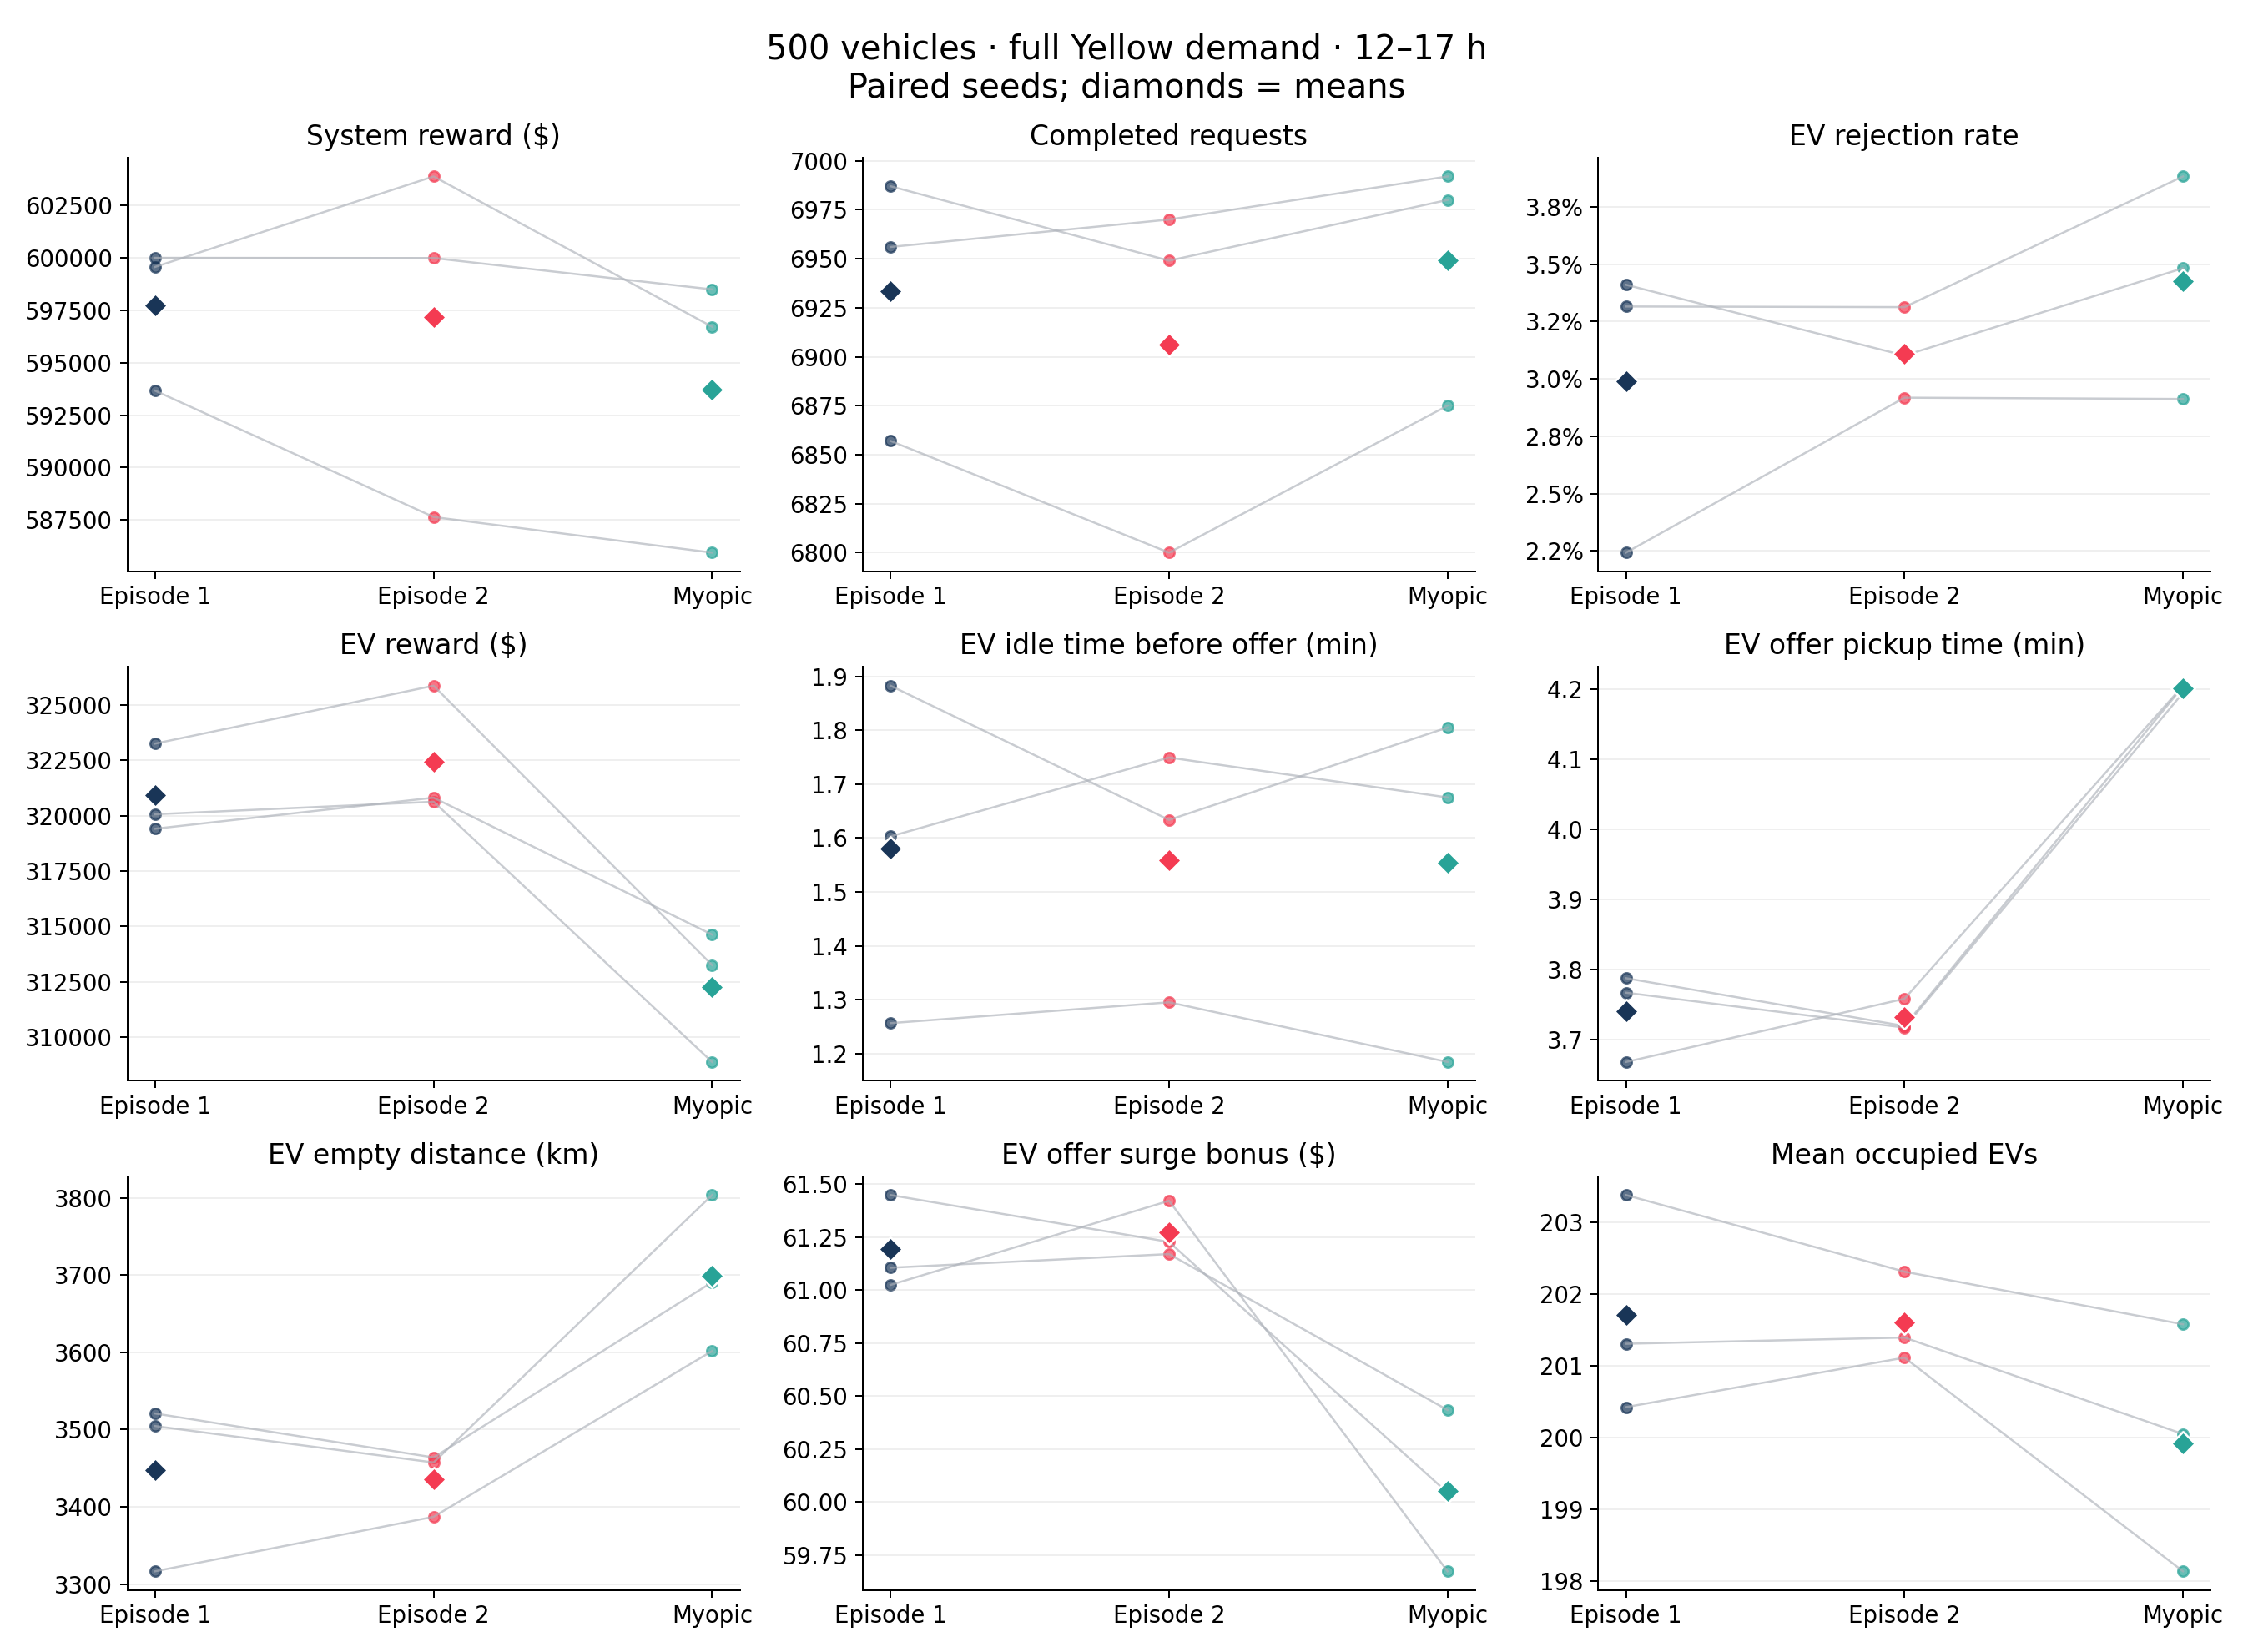

In [2]:
display(Image(filename=str(DATA / "policy_comparison.png")))

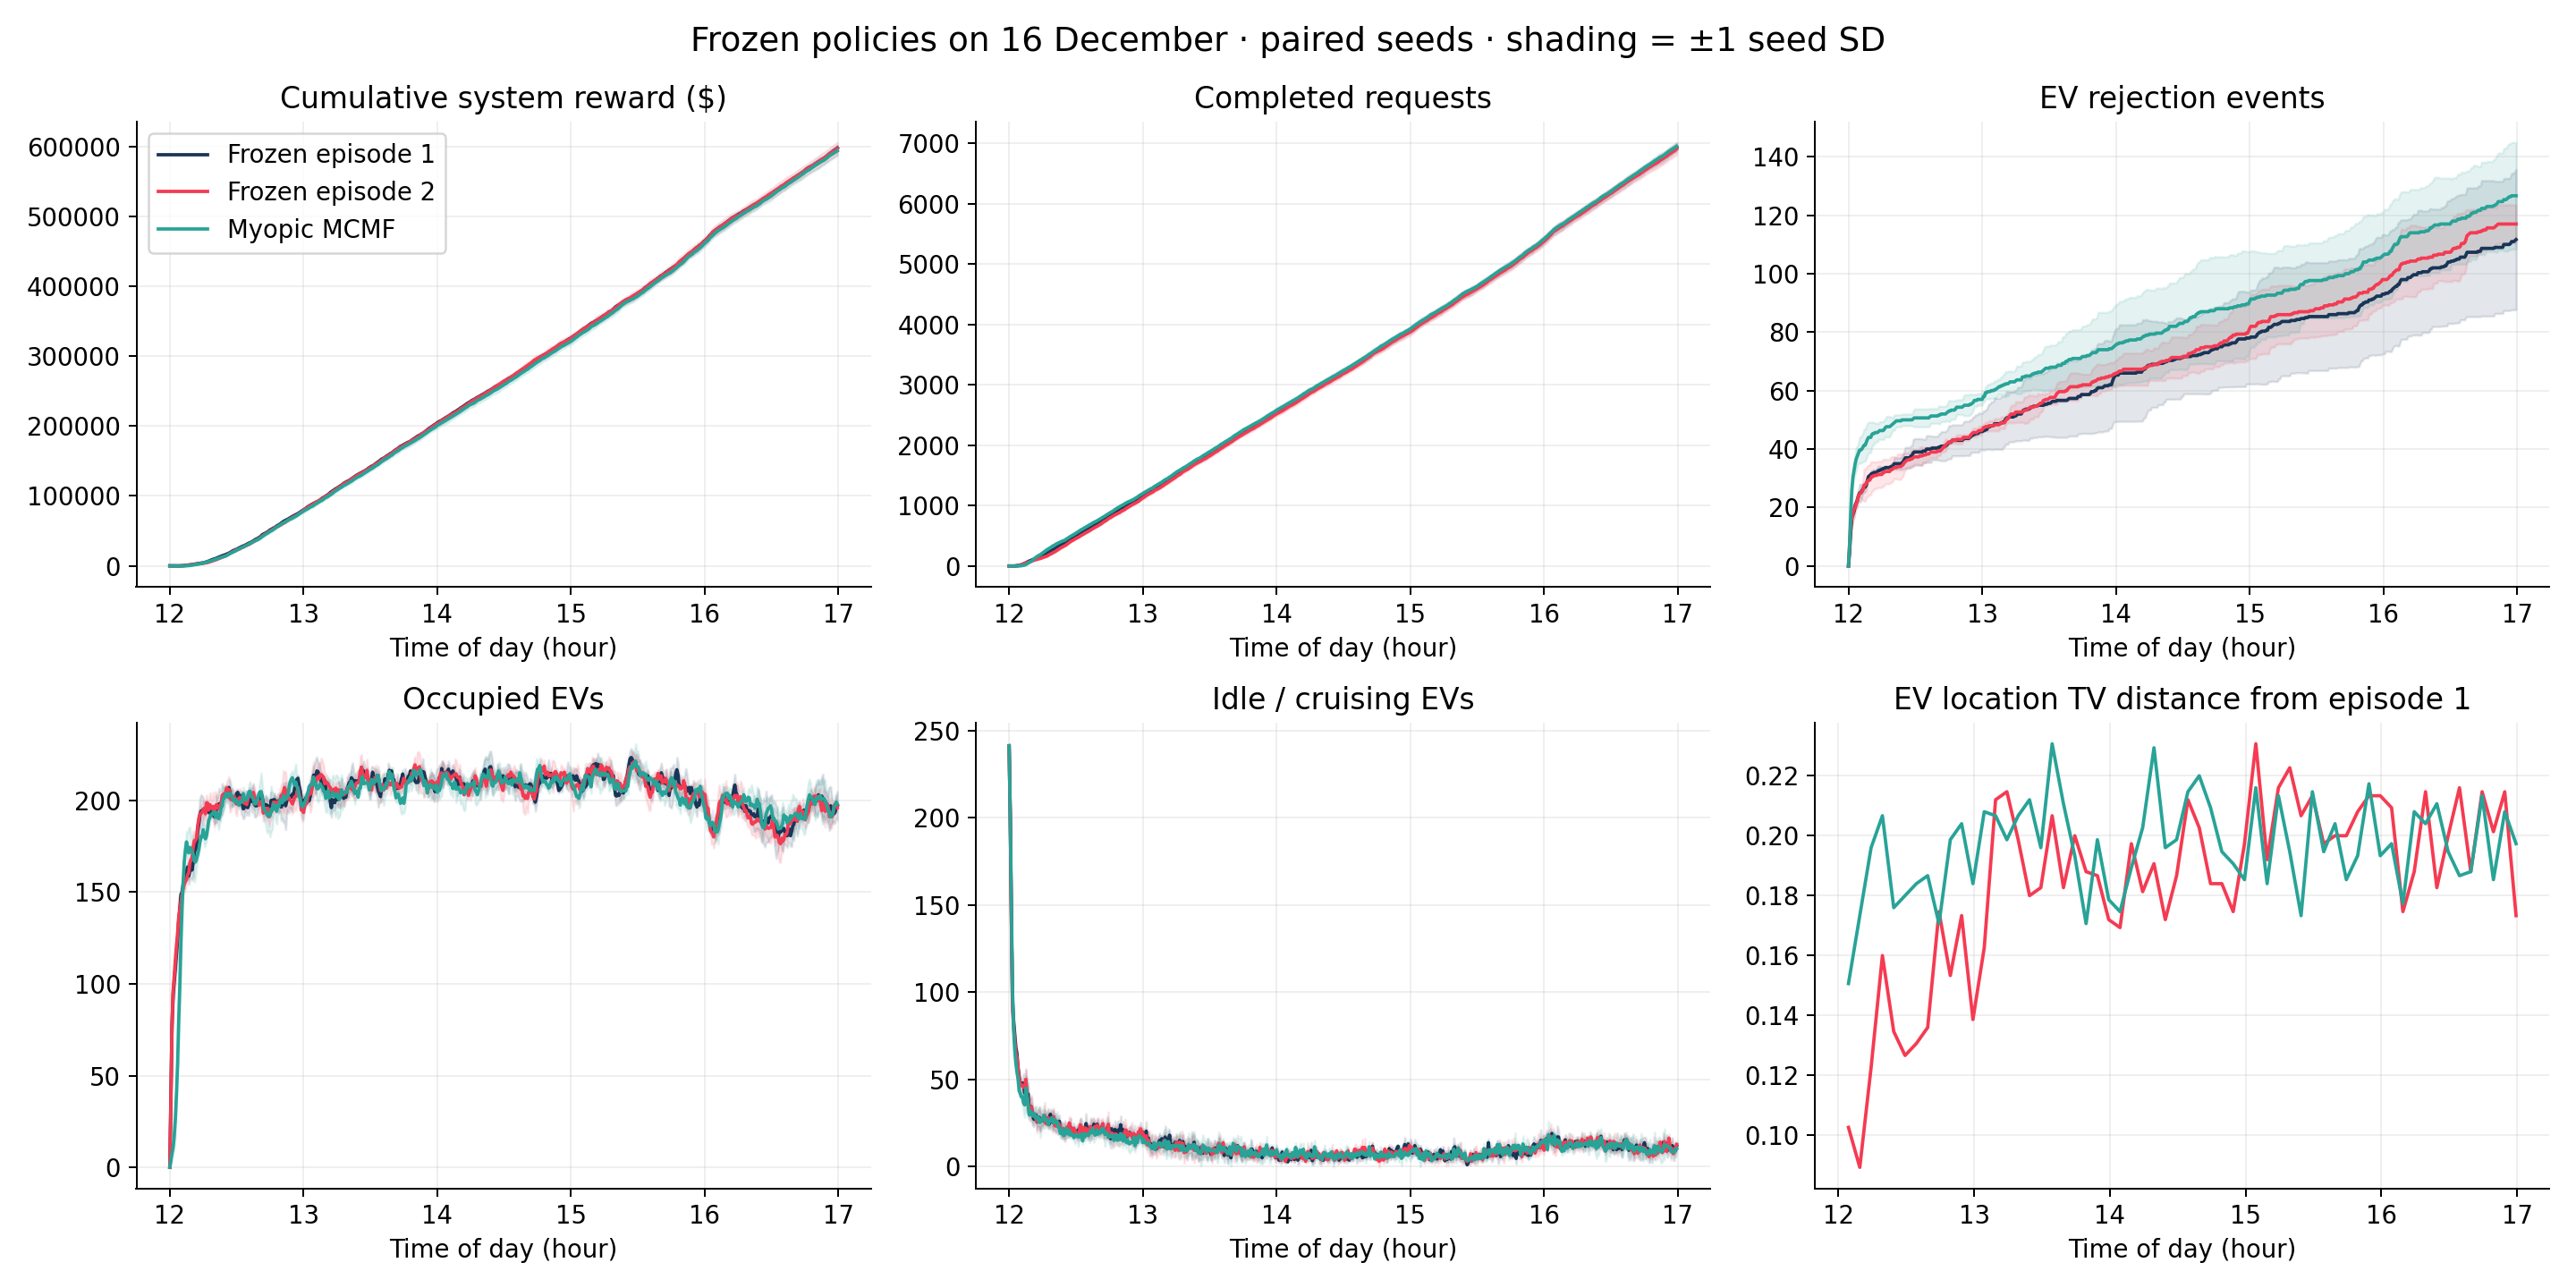

In [3]:
display(Image(filename=str(DATA / "policy_trajectories.png")))

## 检查配对与冻结

初始车辆状态、每步生成订单数量、CRN 身份一致；相同车辆/订单/时间/尝试次数的拒单抽样一致。各方法可以选择不同订单，因此不能要求所有实际拒单结果相同。每个测试组运行前后验证网络权重哈希一致。

In [4]:
json.loads((DATA / "pairing_validation.json").read_text())

[{'seed': 256,
  'left': 'episode1',
  'right': 'episode2',
  'matched_offer_draws': 147,
  'mismatches': 0,
  'same_initial_state_and_demand': True,
  'frozen_weights': True},
 {'seed': 256,
  'left': 'episode1',
  'right': 'myopic',
  'matched_offer_draws': 49,
  'mismatches': 0,
  'same_initial_state_and_demand': True,
  'frozen_weights': True},
 {'seed': 256,
  'left': 'episode2',
  'right': 'myopic',
  'matched_offer_draws': 36,
  'mismatches': 0,
  'same_initial_state_and_demand': True,
  'frozen_weights': True},
 {'seed': 257,
  'left': 'episode1',
  'right': 'episode2',
  'matched_offer_draws': 183,
  'mismatches': 0,
  'same_initial_state_and_demand': True,
  'frozen_weights': True},
 {'seed': 257,
  'left': 'episode1',
  'right': 'myopic',
  'matched_offer_draws': 41,
  'mismatches': 0,
  'same_initial_state_and_demand': True,
  'frozen_weights': True},
 {'seed': 257,
  'left': 'episode2',
  'right': 'myopic',
  'matched_offer_draws': 39,
  'mismatches': 0,
  'same_initial_st

## 第二轮相对第一轮的变化

拒单模型的平均效用为 $1.810-0.017\,idle-0.050\,pickup+0.101\,surge$。

文件中的三项 utility contribution 给出实际 offer 组合的平均效用变化来源；它们不是独立干预的因果效应。总拒单次数同时受派单次数影响，应结合条件拒单率、平均接单概率查看。EV 位置 TV 距离在 0–1 之间，越大表示与第一轮分布差异越大，不表示收益必然下降。

In [5]:
json.loads((DATA / "paired_episode2_minus_episode1.json").read_text())

[{'seed': 256,
  'aev_charging_mean_vehicles': 1.7733333333333339,
  'aev_empty_km': 91.36224252657985,
  'aev_fully_idle_mean_vehicles': -1.1016666666666666,
  'aev_fully_idle_vehicle_steps': -661.0,
  'aev_idle_moving_mean_vehicles': 1.73,
  'aev_onboard_mean_vehicles': -3.6100000000000136,
  'aev_onboard_vehicle_steps': -2166.0,
  'aev_pickup_km': -52.813387841302756,
  'aev_pickup_mean_vehicles': -0.5850000000000009,
  'aev_pickup_vehicle_steps': -351.0,
  'aev_to_charge_mean_vehicles': 1.7933333333333334,
  'charge_finished': 82.0,
  'completed': -38,
  'completed_aev': -64,
  'completed_ev': 26,
  'elapsed_seconds': -2.779620791000525,
  'ev_charging_mean_vehicles': 0.27333333333333343,
  'ev_charging_vehicle_steps': 164.0,
  'ev_empty_km': 70.5374439526322,
  'ev_fully_idle_mean_vehicles': -0.02833333333333332,
  'ev_fully_idle_vehicle_steps': -17.0,
  'ev_idle_moving_mean_vehicles': -0.10333333333333261,
  'ev_idle_moving_vehicle_steps': -62.0,
  'ev_mean_offer_utility': 0.0013

## 原始数据

每个 `episode*_seed*/`、`myopic_seed*/` 下：

- `result.json`：系统收益、分车种收益、订单生命周期及汇总。
- `offers.jsonl`：实际 EV offer、拒单输入、抽样和结果。
- `steps.jsonl`：每个 30 秒步的状态、累计订单、每 10 步的分区车辆数。
- `settings.json`、`run.log`：配置与完整日志。

`checkpoints/` 保存两轮测试权重及 best；不保存 replay 和 optimizer。所有图由上面的 Python 分析代码从原始数据生成，并保存 PNG/PDF。